<h1 style='text-align: center; font-family: Colonna MT; font-size: 25px; font-weight: 600'>CUSTOMER SEGMENTATION ANALYSIS USING MACHINE LEARNING<br>
<span style="text-align:center; font-family:Arial, sans-serif; font-size:16px; color:#555;">
    <strong>Chausiku Kassimu</strong><br>
    Data Analyst | Machine Learning Enthusiast | Python Developer<br>
    📧 <a href="mailto:chausikukassimu1@gmail.com">chausikukassimu1@gmail.com</a>
</span>
</h1>

----

<h1 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>1.0. ENVIRONMENT SETUP </h1>

<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 18px; text-align: left'>1.1. IMPORTING REQUIRED LIBRARIES</h2>

In [221]:
    # ── Data Manipulation Libraries
    from typing import List, Tuple, Union, Dict, Optional
    import datetime as dt, datetime
    import pandas as pd
    import numpy as np
    import warnings
    import logging

    # ── Data Visualizations' Libraries
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ── Scientific Computiong and Statistics Libraries
    from scipy.stats import norm, jarque_bera, shapiro
    from sklearn.preprocessing import MinMaxScaler
    from scipy.stats import skew, kurtosis
    from scipy import stats

    # ── Features Preprocessing and Machin Learning Libraries
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA

<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 18px; text-align: left'>1.2. VISUAL CONFIGURATION</h2>

In [220]:
    logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    pd.set_option('display.max_columns', 100)
    warnings.simplefilter("ignore")
    
    plt.rcParams['font.family']  =  "Arial" 
    plt.rcParams['figure.dpi']   =  100 
    plt.rcParams['font.size'] =  10 

<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>1.3. IMPORTING & PREPROCESSING DATASET</h2>

In [181]:
FILEPATH         =  "Datasets/E-commerce Sales Datasets (2016).csv"
df               =  pd.read_csv(FILEPATH)
df['date']       =  pd.to_datetime(df['date'])
display(df.head(15))

,date,year,quarter,month,customer_id,customer_name,region,zone,txns_id,order_id,sku,quantity,revenue,payment
0,2016-01-02,2016,Q1,January,2547,Laura Smith,Kilimanjaro,Northern,1,1,0EM7L,1.00,313.00,Cash
1,2016-01-02,2016,Q1,January,822,John Martinez,Geita,Lake,2,2,68BRQ,1.00,546.00,Mobile Transfer
2,2016-01-02,2016,Q1,January,3686,William Novak,Dar es Salaam,Coastal,3,3,CZUZX,1.00,635.00,Mobile Transfer
3,2016-01-02,2016,Q1,January,3719,Trevor Sherman,Lindi,Coastal,4,4,549KK,1.00,559.00,Cash
4,2016-01-02,2016,Q1,January,9200,Lisa Gentry,Dar es Salaam,Coastal,5,5,K8EHH,1.00,688.00,Cash
5,2016-01-02,2016,Q1,January,5010,Emily Carr,Kagera,Lake,6,6,GVBRC,1.00,1077.00,Bank Transfer
6,2016-01-02,2016,Q1,January,1666,Katelyn Brown,Singida,Central,7,7,AHAE7,1.00,365.00,Mobile Transfer
7,2016-01-02,2016,Q1,January,1666,Katelyn Brown,Singida,Central,7,7,AHZNS,1.00,821.00,Cash
8,2016-01-02,2016,Q1,January,1253,Shannon Wilkerson,Dar es Salaam,Coastal,8,8,9STQJ,1.00,825.00,Cash
9,2016-01-02,2016,Q1,January,5541,Richard Watson,Rukwa,Southern,9,9,7IE9S,1.00,818.00,Cash


<h1 style='font-family: Bradley Hand ITC; font-size: 25px; font-weight: 600'> 2.0: DATA OVERVIEW AND QUALITY CHECKS</h1>

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 2.1: DATA SHAPE AND COLUMNS</h3>

In [182]:
df.shape

(131706, 14)

In [183]:
for col in df.columns: print("     ---", col)

     --- date
     --- year
     --- quarter
     --- month
     --- customer_id
     --- customer_name
     --- region
     --- zone
     --- txns_id
     --- order_id
     --- sku
     --- quantity
     --- revenue
     --- payment


In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           131706 non-null  datetime64[ns]
 1   year           131706 non-null  int64         
 2   quarter        131706 non-null  object        
 3   month          131706 non-null  object        
 4   customer_id    131706 non-null  int64         
 5   customer_name  131706 non-null  object        
 6   region         131706 non-null  object        
 7   zone           131706 non-null  object        
 8   txns_id        131706 non-null  int64         
 9   order_id       131706 non-null  int64         
 10  sku            131706 non-null  object        
 11  quantity       131706 non-null  float64       
 12  revenue        131706 non-null  float64       
 13  payment        131706 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 2.2: COLUMNS SUMMARIES</h3>

In [185]:
def _audit(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    for col_name in df.columns:
        distinct_values_counts    = df[col_name].value_counts()
        top_10_values_counts      = df[col_name].value_counts().head(10).to_dict()
        distinct_values_counts    = ({k: v for k, v in sorted(top_10_values_counts.items(), key=lambda item: item[1], reverse=True)})
        results.append({
            'col_name':               col_name,
            'col_dtype':              df[col_name].dtype,
            'nulls':           df[col_name].isnull().sum(),
            'non_nulls':       df[col_name].notnull().sum(),
            'distinct_values': df[col_name].nunique(),
            "distinct_values_counts": distinct_values_counts
            })
    
    return pd.DataFrame(results)

display(_audit(df))

,col_name,col_dtype,nulls,non_nulls,distinct_values,distinct_values_counts
0,date,datetime64[ns],0,131706,363,"{2016-09-23 00:00:00: 638, 2016-12-15 00:00:00..."
1,year,int64,0,131706,1,{2016: 131706}
2,quarter,object,0,131706,4,"{'Q4': 35256, 'Q2': 34104, 'Q1': 31274, 'Q3': ..."
3,month,object,0,131706,12,"{'December': 12535, 'May': 12103, 'September':..."
4,customer_id,int64,0,131706,22625,"{1660: 228, 1665: 222, 17104: 218, 1685: 191, ..."
5,customer_name,object,0,131706,19963,"{'Jesse King': 228, 'Diane Morris': 222, 'Dean..."
6,region,object,0,131706,23,"{'Dar es Salaam': 31407, 'Tanga': 11024, 'Arus..."
7,zone,object,0,131706,6,"{'Coastal': 53185, 'Lake': 24947, 'Northern': ..."
8,txns_id,int64,0,131706,64682,"{19098: 21, 1348: 21, 42295: 20, 28731: 19, 16..."
9,order_id,int64,0,131706,64682,"{19098: 21, 1348: 21, 42295: 20, 28731: 19, 16..."


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 2.3: DUPLICATE RECORDS</h3>

In [186]:
df.duplicated().sum()

np.int64(0)

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 2.4: DATA TYPES VALIDATIONS</h3>

In [187]:
def simplify_dtype(dtype):
    if dtype in (int, float, np.number): 
        return 'Numeric'
    elif np.issubdtype(dtype, np.datetime64): 
        return 'Datetime'
    elif dtype == str: 
        return 'String'
    elif dtype == type(None): 
        return 'Missing'
    else: 
        return 'Other'

def _column_dtypes(df: pd.DataFrame)-> pd.DataFrame:
    all_dtypes    =  {'Numeric', 'Datetime', 'String', 'Missing', 'Other'}
    results       =  pd.DataFrame(index=df.columns, columns=list(all_dtypes), dtype=object).fillna('-')
    
    for column in df.columns:
        dtypes       = df[column].apply(lambda x: simplify_dtype(type(x))).value_counts()
        percentages  = (dtypes / len(df)) * 100
        for dtype, percent in percentages.items():
            if percent > 0:
                results.at[column, dtype] = f'{percent:.2f}%'
            else:
                results.at[column, dtype] = '-'
    return results

_column_dtypes(df) 

,Datetime,Missing,String,Numeric,Other
date,-,-,-,-,100.00%
year,-,-,-,100.00%,-
quarter,-,-,100.00%,-,-
month,-,-,100.00%,-,-
customer_id,-,-,-,100.00%,-
customer_name,-,-,100.00%,-,-
region,-,-,100.00%,-,-
zone,-,-,100.00%,-,-
txns_id,-,-,-,100.00%,-
order_id,-,-,-,100.00%,-


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 2.5: OUTLIERS DETECTION</h3>

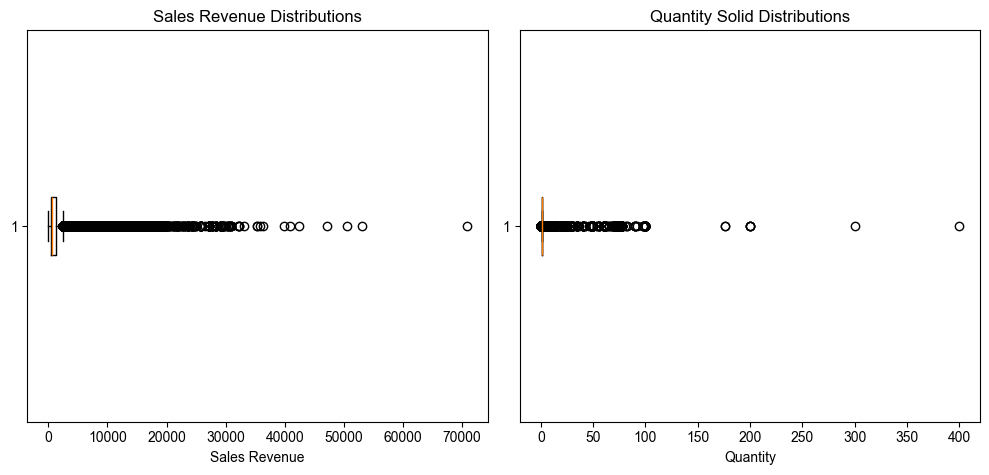

In [188]:
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
    ax1.boxplot(df["revenue"], orientation="horizontal")
    ax1.set_title("Sales Revenue Distributions")
    ax1.set_xlabel("Sales Revenue")
    
    ax2.boxplot(df["quantity"], orientation="horizontal")
    ax2.set_title("Quantity Solid Distributions")
    ax2.set_xlabel("Quantity")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

<h1 style='color: red; font-family: Bradley Hand ITC; font-weight: 600; font-size: 25px; text-align: left'>3.0. CUSTOMER FEATURES ENGINEERING </h1>

<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>3.1. RECENCY, MONETARY FREQUENCY FEATURES</h2>

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Number of transactions made by each customer.
- **Monetary (M):** Total revenue generated by each customer.

In [189]:
    min_date     =  df.groupby("customer_id")["date"].min()
    max_date     =  df.groupby("customer_id")["date"].max()
    last_date    =  df["date"].max() + pd.Timedelta(days=1)
    
    recency      =  (last_date - max_date).dt.days 
    frequency    =  (df.groupby("customer_id")["txns_id"].nunique())
    monetary     =  (df.groupby("customer_id")["revenue"].sum())
    print("\n[1/4] Features Created Successfully\n")


[1/4] Features Created Successfully



<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>3.2. ADDITIONAL CUSTOMERS FEATURES</h2>

- **Average Order Value (AOV):** Average amount spent per transaction.
- **Customer Lifetime Value (CLTV):**
- **Total Quantity Purchased:**
- **Average Basket Size:** Average number of items per transaction.
- **Number of Products Purchased:** Measures product variety.
- **Average Revenue per Item:**
- **Purchase Span:** How long the customer has been active.
- **Purchase Interval:** Average days between purchases.
- **Payment Preferences:** Payment method preferences

In [190]:
    aov          =  (df.groupby("customer_id")
                     .apply(lambda x: x["revenue"]
                     .sum() / x["txns_id"]
                     .nunique()))
    
    lifespan     =  ((last_date - min_date).dt.days) / 365
    cltv         =  aov * frequency * lifespan
    total_qty    =  (df.groupby("customer_id")["quantity"].sum()) 
    basket_size  =  (total_qty / frequency)                                       
    
    product_diversity  = (df.groupby("customer_id")["sku"].nunique())
    revenue_per_item   = (monetary / total_qty)
    purchase_span      = (max_date - min_date).dt.days
    purchase_interval  = (purchase_span / (frequency - 1)).fillna(0)

    print("\n[2/4] Features Created Successfully\n")


[2/4] Features Created Successfully



In [87]:
    customer_region     = (df.groupby("customer_id")["region"].agg(lambda x: x.mode().iloc[0]))
    customer_zone       = (df.groupby("customer_id")["zone"].agg(lambda x: x.mode().iloc[0]))
    payment_pref        = (pd.crosstab(df["customer_id"], df["payment"], normalize="index"))
    payment_share       = (pd.crosstab(
                                df["customer_id"],
                                df["payment"],
                                values=df["revenue"],
                                aggfunc="sum",
                                normalize="index"
                                ).fillna(0)
                            )
    print("\n[3/4] Features Created Successfully\n")


[3/4] Features Created Successfully



In [191]:
    features = pd.DataFrame({
                "recency":               recency,
                "frequency":             frequency,
                "monetary":              monetary,
                "oav":                   aov,
                "cltv":                  cltv,
                "total_qty":             total_qty,
                "basket_size":           basket_size,
                "product_diversity":     product_diversity,
                "revenue_per_item":      revenue_per_item,
                "Purchase_Span":         purchase_span,
                "purchase_interval":     purchase_interval,
                "customer_region":       customer_region,
                "customer_zone":         customer_zone
                })
    
    features = features.join(payment_share)
    print("\n[4/4] Features DataFrame Created Successfully\n")


[4/4] Features DataFrame Created Successfully



<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>3.3. FEATURES PREVIEW</h2>

In [192]:
display(features.head(15))

,recency,frequency,monetary,oav,cltv,total_qty,basket_size,product_diversity,revenue_per_item,Purchase_Span,purchase_interval,customer_region,customer_zone,Bank Transfer,Cash,Mobile Transfer
customer_id,,,,,,,,,,,,,,,,
1,345,1,1629.00,1629.00,1539.74,2.00,2.00,2,814.50,0,0.00,Unguja,Zanzibar,0.00,0.00,1.00
2,196,2,2277.00,1138.50,1765.45,2.00,1.00,2,1138.50,87,87.00,Dar es Salaam,Coastal,0.00,0.34,0.66
3,365,1,1092.00,1092.00,1092.00,4.00,4.00,3,273.00,0,0.00,Arusha,Northern,0.00,0.25,0.75
4,53,2,3329.00,1664.50,1586.98,5.00,2.50,5,665.80,121,121.00,Mwanza,Lake,0.00,0.74,0.26
5,180,5,7882.00,1576.40,7061.41,14.00,2.80,2,563.00,147,36.75,Dar es Salaam,Coastal,0.00,0.82,0.18
6,276,1,2555.00,2555.00,1932.00,3.00,3.00,3,851.67,0,0.00,Kilimanjaro,Northern,0.00,0.57,0.43
7,88,1,1784.00,1784.00,430.12,1.00,1.00,1,1784.00,0,0.00,Dar es Salaam,Coastal,1.00,0.00,0.00
8,194,1,978.00,978.00,519.81,2.00,2.00,1,489.00,0,0.00,Dar es Salaam,Coastal,0.00,1.00,0.00
9,287,1,1575.00,1575.00,1238.42,1.00,1.00,1,1575.00,0,0.00,Kilimanjaro,Northern,0.00,1.00,0.00


<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>3.4. FEATURES STATISTICS DESCRIPTION'S </h2>

In [206]:
def _statistics(df: pd.DataFrame, variables: Optional[List[str]] = None, group: Optional[str] = None) -> pd.DataFrame:
    grouped  = df.groupby(group) if group else [(None, df)]
    results  = []
    
    for variable in variables:
        for name, df in grouped:
            counts        =  df[variable].count()
            mean_val      =  df[variable].mean()
            median_val    =  df[variable].median()
            mode_val      =  df[variable].mode().iloc[0] if not df[variable].mode().empty else np.nan
            std_dev       =  df[variable].std()
            variance      =  df[variable].var()
            value_range   =  df[variable].max() - df[variable].min()
            iqr           =  df[variable].quantile(0.75) - df[variable].quantile(0.25)
            
            skewness_val  =  skew(df[variable], nan_policy='omit')
            kurtosis_val  =  kurtosis(df[variable], nan_policy='omit')
            jb_stat, jb_p =  jarque_bera(df[variable])
            jb_p_interp   =  'Non-Normal' if jb_p < 0.05 else 'Normal'
            jb_p_fmt      =  f'<0.05' if jb_p < 0.05 else f'{jb_p:.3f}'
    
            results.append({
                'Variables':       variable,
                group if group else 'None': name,
                'Counts':       counts,
                'Mean':         mean_val,
                'Median':       median_val,
                'Mode':         mode_val,
                'Std':          std_dev,
                'Variance':     variance,
                'Range':        value_range,
                'IQR':          iqr,
                'Skewness':     skewness_val,
                'Kurtosis':     kurtosis_val,
                'JB p-value':   jb_p_fmt,
                'JB Notes':     jb_p_interp,
            })
    results = pd.DataFrame(results)
    results = results.drop(columns=['None']) if group is None else results
    return results

if __name__ == "__main__":
    variables = features.select_dtypes(include=[np.number]).columns
    results    = _statistics(features, variables)
    display(results)

,Variables,Counts,Mean,Median,Mode,Std,Variance,Range,IQR,Skewness,Kurtosis,JB p-value,JB Notes
0,recency,22625,162.10,150.00,10.00,115.92,13438.28,364.00,224.00,0.14,-1.45,<0.05,Non-Normal
1,frequency,22625,2.86,1.00,1.00,4.00,16.00,98.00,2.00,6.39,81.73,<0.05,Non-Normal
2,monetary,22625,6974.76,2385.00,675.00,15230.78,231976565.70,398580.00,5290.00,7.43,97.98,<0.05,Non-Normal
3,oav,22625,2175.91,1344.33,675.00,2834.60,8034933.49,54465.00,1674.00,5.22,45.26,<0.05,Non-Normal
4,cltv,22625,4818.34,1272.79,286.03,11803.72,139327779.58,317782.19,3572.48,7.83,108.82,<0.05,Non-Normal
5,total_qty,22625,8.65,3.00,1.00,20.98,440.35,814.57,6.00,11.21,232.06,<0.05,Non-Normal
6,basket_size,22625,2.74,2.00,1.00,5.68,32.31,407.75,2.00,30.97,1655.27,<0.05,Non-Normal
7,product_diversity,22625,4.71,3.00,1.00,6.16,38.01,175.00,5.00,6.05,92.03,<0.05,Non-Normal
8,revenue_per_item,22625,916.69,696.92,675.00,937.81,879493.97,24270.91,535.75,6.99,89.74,<0.05,Non-Normal
9,Purchase_Span,22625,57.09,0.00,0.00,83.75,7013.93,364.00,93.00,1.34,0.51,<0.05,Non-Normal


<h1 style='color: red; font-family: Bradley Hand ITC; font-weight: 600; font-size: 25px; text-align: left'>4.0. CUSTOMER CLUSTERING AND SEGMENTATION </h1>

<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>4.1. FEATURES DEFINITION</h2>

In [195]:
num_cols       = ['recency', 'frequency', 'monetary', 'oav', 'cltv', 'total_qty', 'basket_size', 
                  'product_diversity', 'revenue_per_item', 'Purchase_Span', 
                  'purchase_interval']

cat_cols        = [] #  ['customer_region','customer_zone'] 
payment_cols    = [] #  ['Bank Transfer', 'Cash', 'Mobile Transfer']
payment_cols    = [] #  ['Bank Transfer', 'Cash', 'Mobile Transfer']

<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>4.2. FEATURES PREPROCESSING PIPELINE</h2>

In [196]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('payment', 'passthrough', payment_cols)
])
display(preprocessor)

,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>4.3. K-MEANS CLUSTERING </h2>

In [197]:
X                    =  preprocessor.fit_transform(features)
pca                  =  PCA(n_components=0.95, random_state=42)
X_pca                =  pca.fit_transform(X)
kmeans               =  KMeans(n_clusters=5, random_state=42, n_init='auto')
clusters             =  kmeans.fit_predict(X_pca)
features['cluster']  =  clusters

<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>4.3. K-CLUSTERS PROFILING</h2>

In [198]:
profile = (features.groupby('cluster')
        .agg(customers=('cluster','size'),
                avg_revenue=('monetary','mean'),
                avg_frequency=('frequency','mean'),
                avg_recency=('recency','mean'),
                purchase_interval=('purchase_interval','mean'),
                purchase_span=('Purchase_Span','mean'),
                product_diversity=('product_diversity','mean')
                ).reset_index()
                )

display(profile)

,cluster,customers,avg_revenue,avg_frequency,avg_recency,purchase_interval,purchase_span,product_diversity
0,0,15319,2422.91,1.50,199.57,6.10,9.95,2.54
1,1,196,117009.83,25.14,25.56,13.82,255.79,38.59
2,2,783,21121.28,1.76,189.62,17.90,29.55,5.21
3,3,1583,31661.82,11.08,70.44,23.42,201.79,17.58
4,4,4744,6554.53,3.78,72.76,79.13,157.37,5.95


<h2 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>4.4. CLUSTERS BUSSINESS LABELS ASSIGNMENT</h2>

- **Champions**: *High monetary*, *High frequency*, *High CLTV*, *Low recency*, *High product diversity*
- **Loyal Customers**: *Moderate-high frequency*, *Stable purchase intervals*, *Long purchase span*
- **Big Spenders**: *High OAV*, *High revenue per item*, *Lower frequency*
- **Occasional Buyers**: *Medium spend*, *Irregular purchase intervals*, *Moderate recency*
- **At Risk Customers**: *High recency*, *Low frequency*, *Low CLTV*, *Small basket sizes*

In [199]:
Z         = features[num_cols].apply(lambda x: (x - x.mean()) / x.std()).add_suffix("_z")
z_cols    = [c for c in features.columns if c.endswith("_z")]
sc_cols   = [c for c in features.columns if c.endswith("_Score")]
features  = features.drop(columns=z_cols + sc_cols, errors="ignore")
features  = pd.concat([features, Z], axis=1)

features["Champion"] = (
        0.25*features["frequency_z"]
        + 0.25*features["monetary_z"]
        + 0.25*features["cltv_z"]
        + 0.15*features["product_diversity_z"]
        - 0.10*features["recency_z"]
        )

features["Loyal Customer"] = (
        0.40*features["frequency_z"]
        + 0.35*features["Purchase_Span_z"]
        - 0.25*features["purchase_interval_z"]
        )

features["Big Spender"] = (
         0.50*features["oav_z"]
        + 0.35*features["revenue_per_item_z"]
        - 0.15*features["frequency_z"]
        )

features["Occasional Buyer"] = (
      -np.abs(features["monetary_z"])
      -np.abs(features["recency_z"])
      +features["purchase_interval_z"]
      )

features["At Risk Customer"] = (
      0.40*features["recency_z"]
    - 0.25*features["frequency_z"]
    - 0.25*features["cltv_z"]
    - 0.10*features["basket_size_z"]
    )

In [201]:
scores              = ["Champion","Loyal Customer", "Big Spender", "Occasional Buyer", "At Risk Customer"]
cluster_scores      = (features.groupby("cluster")[scores].mean())
segment_map         = (cluster_scores.idxmax(axis=1).to_dict())
display(cluster_scores)

,Champion,Loyal Customer,Big Spender,Occasional Buyer,At Risk Customer
cluster,,,,,
0,-0.31,-0.23,-0.09,-1.64,0.29
1,5.95,3.12,-0.07,-8.68,-3.75
2,0.34,-0.19,2.86,-1.99,-0.15
3,1.71,1.42,-0.09,-2.69,-1.26
4,0.14,0.16,-0.14,0.26,-0.35


In [215]:
features['segment'] = features['cluster'].map(segment_map)
profile = (features.groupby('segment')
        .agg(customers=('segment','size'),
                avg_revenue=('monetary','mean'),
                avg_frequency=('frequency','mean'),
                avg_recency=('recency','mean'),
                purchase_interval=('purchase_interval','mean'),
                purchase_span=('Purchase_Span','mean'),
                product_diversity=('product_diversity','mean')
                ).reset_index()
                )

display(profile)

,segment,customers,avg_revenue,avg_frequency,avg_recency,purchase_interval,purchase_span,product_diversity
0,At Risk Customer,15319,2422.91,1.50,199.57,6.10,9.95,2.54
1,Big Spender,783,21121.28,1.76,189.62,17.90,29.55,5.21
2,Champion,1779,41064.98,12.63,65.49,22.37,207.74,19.89
3,Occasional Buyer,4744,6554.53,3.78,72.76,79.13,157.37,5.95


In [216]:
variables  = ["monetary", "frequency", "recency", "purchase_interval"]
results    = _statistics(features, variables, "segment")
results[results.columns[:-2]]

,Variables,segment,Counts,Mean,Median,Mode,Std,Variance,Range,IQR,Skewness,Kurtosis
0,monetary,At Risk Customer,15319,2422.91,1449.00,675.00,2765.79,7649610.57,24847.00,2247.50,2.84,10.86
1,monetary,Big Spender,783,21121.28,16798.00,4492.00,16672.63,277976700.77,153766.00,17881.00,2.29,9.26
2,monetary,Champion,1779,41064.98,30332.00,14017.00,35629.90,1269490019.56,395844.00,28152.50,3.41,19.99
3,monetary,Occasional Buyer,4744,6554.53,5235.50,1517.00,4905.69,24065759.06,34628.00,6057.75,1.36,1.97
4,frequency,At Risk Customer,15319,1.50,1.00,1.00,1.03,1.05,10.00,1.00,2.92,10.83
5,frequency,Big Spender,783,1.76,1.00,1.00,1.17,1.37,6.00,1.00,1.74,2.76
6,frequency,Champion,1779,12.63,11.00,10.00,8.37,70.09,96.00,7.00,3.76,25.57
7,frequency,Occasional Buyer,4744,3.78,3.00,2.00,1.89,3.58,12.00,3.00,1.14,0.89
8,recency,At Risk Customer,15319,199.57,224.00,284.00,109.27,11939.38,364.00,198.00,-0.30,-1.27
9,recency,Big Spender,783,189.62,208.00,289.00,112.14,12574.45,364.00,210.50,-0.20,-1.40


---
<h1 style='text-align: center; font-family: Colonna MT; font-size: 30px; font-weight: 600'>Data to Drive Meaningful Insights and Solutions<br>
    <span style="text-align:center; font-family:Arial, sans-serif; font-size:16px; color:#555;">
        <strong>Chausiku Kassimu</strong><br>
        Data Analyst | Machine Learning Enthusiast | Python Developer<br>
        📧 <a href="mailto:chausikukassimu1@gmail.com">chausikukassimu1@gmail.com</a>
    </span>
    </h1>

---